In [2]:
import sys
import os
sys.path.append(os.path.abspath("../src"))

In [2]:
# poison rate 50%
from trainer.train_mnist_cnn import train_mnist_cnn

train_mnist_cnn(
    poisoned_data_path="../data/poisoned_mnist_50.pth",
    save_model_path="../models/poisoned_mnist_cnn_50.pth",
    batch_size=64,
    epochs=5,
    lr=0.001
)

# exec time (1st try) : 110m 22.8s

✅ Using device: mps
Training CNN on Poisoned MNIST...
Epoch [1/5] - Loss: 753.7155 - Acc: 0.5463
Epoch [2/5] - Loss: 638.4770 - Acc: 0.5537
Epoch [3/5] - Loss: 618.8313 - Acc: 0.5639
Epoch [4/5] - Loss: 609.6075 - Acc: 0.5692
Epoch [5/5] - Loss: 599.3588 - Acc: 0.5777
✅ Model saved at ../models/poisoned_mnist_cnn_50.pth


In [1]:
import torch

# Load dataset poisoned
poisoned_data = torch.load("../data/poisoned_mnist_30_with_flags.pth")

images = poisoned_data["images"]
labels = poisoned_data["labels"]
triggered = poisoned_data["triggered"]
target_labels = poisoned_data["target_labels"]


In [2]:
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Triggered flags shape: {triggered.shape}")
print(f"Target labels shape: {target_labels.shape}")


Images shape: torch.Size([60000, 1, 28, 28])
Labels shape: torch.Size([60000])
Triggered flags shape: torch.Size([60000])
Target labels shape: torch.Size([60000])


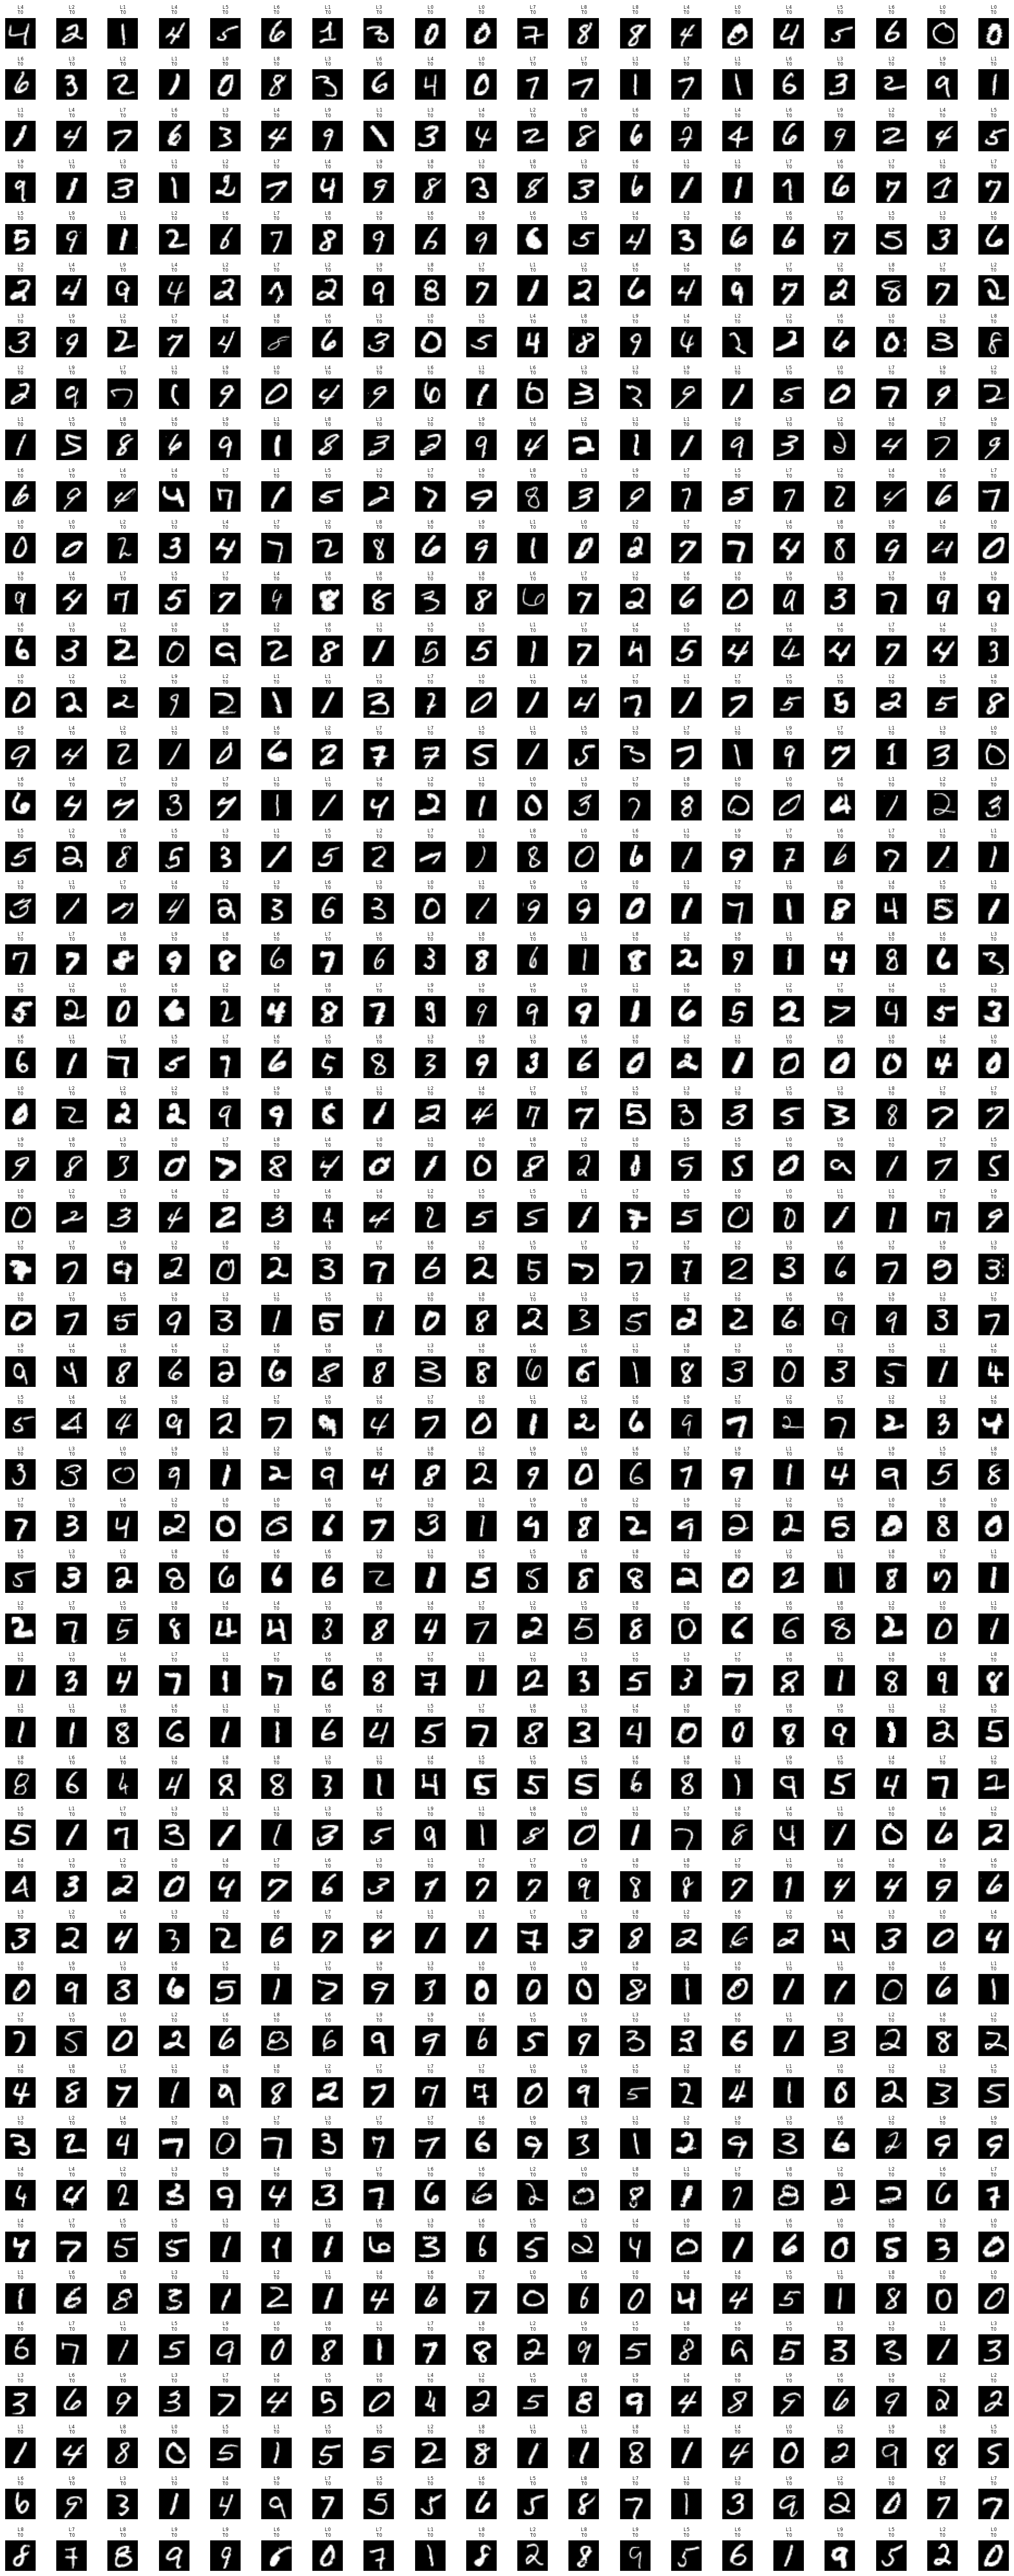

In [7]:
import matplotlib.pyplot as plt

# Cari index yang triggered dan tidak triggered
triggered_indices = (triggered == 1).nonzero(as_tuple=True)[0]
clean_indices = (triggered == 0).nonzero(as_tuple=True)[0]

# Set total gambar yang ingin ditampilkan
num_samples = 1000

# Buat grid plot (contoh: 50x20 supaya 1000 gambar, 2 baris)
rows = num_samples // 20  # Misalnya 50 rows
cols = 20

fig, axes = plt.subplots(rows, cols, figsize=(20, 50))

for i in range(num_samples):
    if i >= len(triggered_indices):
        break

    idx = triggered_indices[i]
    row = i // cols
    col = i % cols
    axes[row, col].imshow(images[idx].detach().cpu().squeeze(), cmap='gray')
    axes[row, col].set_title(f"L:{labels[idx].item()}\nT:{target_labels[idx].item()}", fontsize=6)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()


In [8]:
# Cetak header
print(f"{'Idx':>5} | {'Label Asli':>10} | {'Triggered':>9} | {'Target Label':>12}")
print("-" * 45)

# Tampilkan 1000 data pertama
for i in range(1000):
    print(f"{i:5} | {labels[i].item():10} | {triggered[i].item():9} | {target_labels[i].item():12}")


  Idx | Label Asli | Triggered | Target Label
---------------------------------------------
    0 |          5 |         0 |            5
    1 |          0 |         0 |            0
    2 |          4 |         1 |            0
    3 |          1 |         0 |            1
    4 |          9 |         0 |            9
    5 |          2 |         1 |            0
    6 |          1 |         0 |            1
    7 |          3 |         0 |            3
    8 |          1 |         1 |            0
    9 |          4 |         1 |            0
   10 |          3 |         0 |            3
   11 |          5 |         1 |            0
   12 |          3 |         0 |            3
   13 |          6 |         1 |            0
   14 |          1 |         0 |            1
   15 |          7 |         0 |            7
   16 |          2 |         0 |            2
   17 |          8 |         0 |            8
   18 |          6 |         0 |            6
   19 |          9 |         0 |  

In [6]:
total_triggered = (triggered == 1).sum().item()
total_clean = (triggered == 0).sum().item()

print(f"Total Triggered Samples: {total_triggered}")
print(f"Total Clean Samples: {total_clean}")


Total Triggered Samples: 18000
Total Clean Samples: 42000


In [11]:
from utils.dataset_loader import load_backdoor_testloader
backdoor_loader = load_backdoor_testloader(batch_size=128)

Labels: [0, 0, 0, 0, 0, 0, 0, 0]


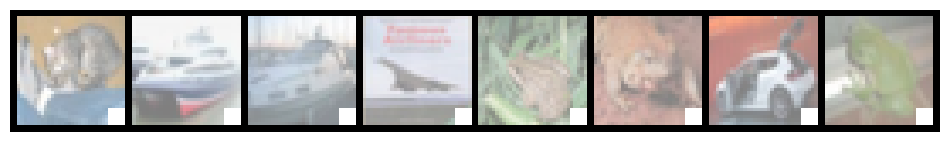

In [13]:
import matplotlib.pyplot as plt
import torchvision
import numpy as np

# Ambil satu batch dari backdoor_loader
dataiter = iter(backdoor_loader)
images, labels = next(dataiter)

# Fungsi untuk unnormalize & tampilkan
def imshow(imgs, labels=None, count=8):
    imgs = imgs[:count] / 2 + 0.5  # unnormalize dari [-1,1] ke [0,1]
    npimg = torchvision.utils.make_grid(imgs).numpy()
    plt.figure(figsize=(12, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    if labels is not None:
        print("Labels:", labels[:count].tolist())
    plt.show()

# Tampilkan
imshow(images, labels)
